## 생성 모델

분류모델: SVM, 로지스틱 회귀분석 (2개 더있었는데.. 의사결정트리랑)

- 생성 모델: 주어진 학습 데이터를 학습해, 학습 데이터의 분포를 따르는 유사한 데이터를 생성하는 모델  
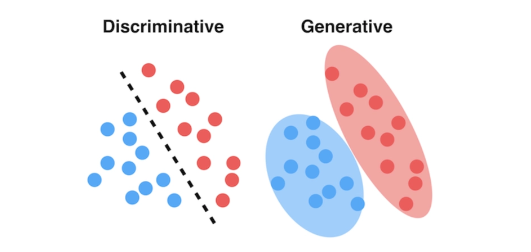

 분류 모델: 입력된 데이터가 어떤 레이블에 속할지 결정하는 모델
 한계: 본 적 없는 이상한 데이터가 들어와도, 외계인 사진을 고양이 개 중 하나로 결정내려야 함.

생성 모델: 샘플을 레이블 지정하는 데는 관심 X
    - 데이터 자체의 확률 분포 P(x)를 학습하여, 학습 데이터와 유사한 새로운 데이터를 만들어내는 모델
- 학습 목표: 세상에 존재할 법한 데이터 X 자체의 확률 분포 ㅠㅏ악
- 특징: 불합리하거나 이상한 입력에 대해서는 "이건 세상에 존재할 확률이 거의 0이야" 라고 판단하며 거부할 수 있는 능력을 갖춤.

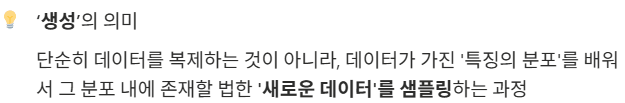

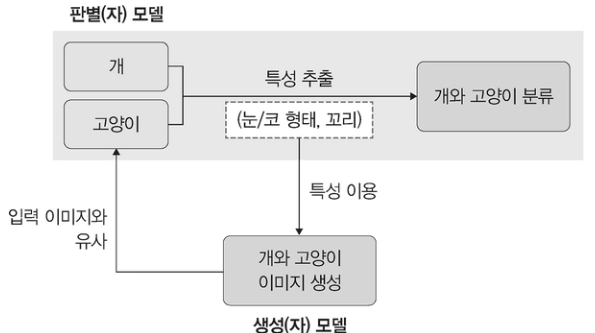

생성 모델 : 고양이의 생김새, 털의 질감, 귀의 모양 등 고양이의 본질적인 특성을 학습하는 방식. 원리를 깨우쳤기 때문에 "고양이 한 마리 그려봐"라고 했을 때 새로운 그림을 그려낼 수 있음

    - 확률의 기본 성질상(정규화 제약), 모든 가능한 이미지(X)의 확률을 다 더하면 반드시 1이 되어야 합니다. 그런데 모델은 한정된 1이라는 확률을 어떤 이미지에 더 많이 줄지 고민해야 합니다. 따라서 생성 모델은 "진짜 고양이 같은 이미지"에는 높은 확률을, "무작위 노이즈 이미지"에는 아주 낮은 확률을 할당하며 세상의 모든 이미지들 사이에서 경쟁을 시킵니다. 이 과정에서 모델은 "다리가 세 개인 개 이미지는 팔이 세 개인 원숭이 이미지보다 높은 확률을 가져야 하는가?" 같은 깊은 구조적 질문에 답해야 하므로 훨씬 복잡한 학습이 필요합니다. 
    개는 실제 세상에 존재하는 동물이라 다리가 하나 빠져도 그나마 현실적이지만, 팔이 세 개인 원숭이는 더 비현실적이라 확률이 낮아야 할 것 같죠? 그런데 모델이 이를 스스로 판단하는 게 얼마나 어려운 일인지 생각해보시면 이해가 됨



생성 모델은 "확률 밀도(Probability Density)를 직접 계산할 수 있는가?"에 따라 
명시적 모델과 암시적 모델로 분류됨

- 명시적? 암시적? → 요리로 비유해볼까요?
- 명시적 모델: 재료 함량(P(X))이 정확히 적힌 레시피 북과 같아요.
- 암시적 모델: 레시피는 비밀이지만, 주문하면 똑같은 맛의 요리(샘플)를 내어주는 요리사~

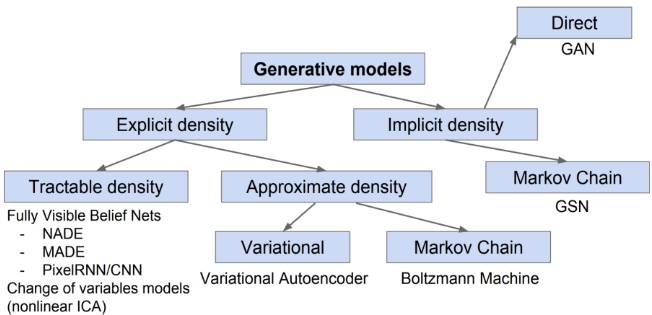

1) 명시적 확률밀도 모델(Explicit density Models)
- 모델이 데이터의 확률 분포인 P(X)의 값을 직접적으로 수치화하여 출력할 수 있는 모델

- 정확히 계산 가능한 모델 (Tractable Density)
    - 수학적으로 확률 값을 정확하게 계산할 수 있음
    - 예시: 자기회귀 모델 (Auto-regressive Models) : 픽셀 하나하나를 순서대로 예측하며 전체 확률을 곱해서 구합니다.

- 근사적 밀도 모델 (Approximate Density)
    - 확률 값을 정확히 구하기는 너무 복잡해서, 그 근삿값이나 하한선(Lower Bound)을 계산
    - 예시: VAE (Variational AutoEncoder) : 정확한 확률 대신 '변이적 하한(ELBO)'이라는 수치를 최대화하는 방식으로 학습합니다

2) 암시적 확률밀도 모델(Implicit density Models)
- 데이터의 확률 분포 P(X)가 무엇인지 수치로 알려주지는 않지만, 그 분포를 따르는 데이터를 생성(Sampling)할 수는 있는 모델
    - 직접 샘플링 : 신경망을 한 번 통과시키는 것만으로 데이터를 바로 만들어냄
    - 예시 GAN (Generative Adversarial Network) : 가짜와 진짜를 비교하며 샘플링 능력을 키웁니다.
- 간접/반복적 샘플링 (마르코브 체인) : 여러 단계를 거쳐 점진적으로 데이터를 완성



2. AE, VAE

2.1 AE

1) Auto Encoder(AE)란?
- 오토인코더는 입력과 동일한 출력을 만드는 것을 목적으로 하는 신경망입니다.
- 차원 축소, 특징 추출, 노이즈 제거, 이상 탐지 등 데이터 복원이나 특성 학습에 많이 사용됩니다.

- 우리가 알던 인코더/디코더와 뭐가 다른가요?
    - 지난 세션까지 배웠던 일반적인 인코더/디코더와 AE의 결정적인 차이는 '목적'에 있습니다.
    - 일반적인 인코더/디코더: 고양이를 보고 '고양이'라는 정답(레이블)을 맞히거나, 한국어를 영어로 번역하는 등 특정 태스크를 수행하기 위해 특징을 추출합니다.
    - AutoEncoder (AE): 정답지가 없습니다(비지도 학습). 대신 "입력 데이터(X)를 그대로 다시 그려내라(X′)"는 숙제를 줍니다.
        - 자기 자신을 다시 만들어야 하므로 'Auto(자기 자신)' + 'Encoder'라는 이름이 붙었습니다.

2) AE의 구조와 작동 : 넣고, 줄이고, 다시 키우기!
- 우선 AE의 작동 과정을 간단히 이해해볼까요?
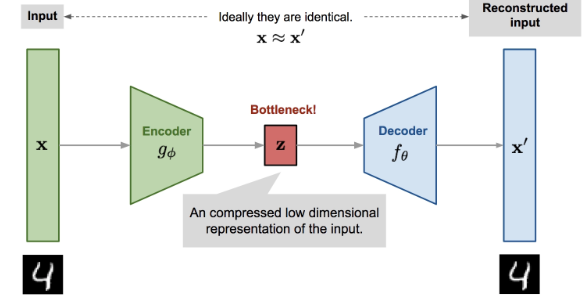  

오토인코더의 앞단을 인코더(Encoder), 뒷단을 디코더(Decoder)라고 부릅니다. 


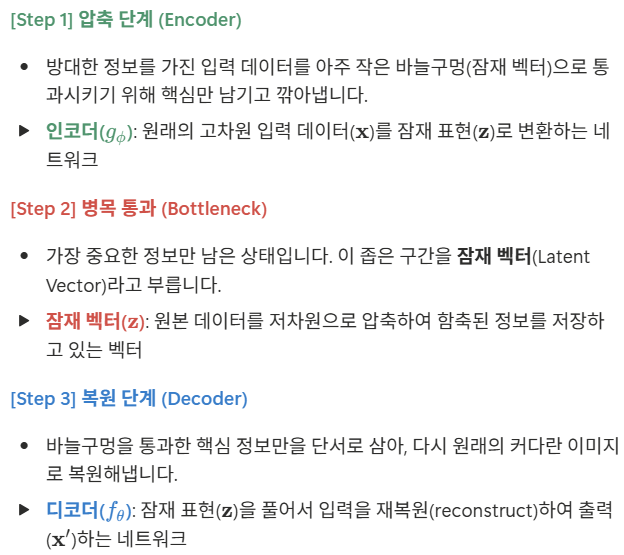


결국, AE는 인코더로 들어가는 입력 데이터 
𝑥
x﻿와 디코더가 출력한 데이터 
𝑥
′
x 
′
 ﻿가 같아지도록 훈련하여 그 과정에서 데이터의 가장 중요한 특징(잠재 벡터)만 남기게 되는 모델입니다.

 왜 굳이 작게 줄였다가 다시 키우나요?
- 만약 줄이는 과정 없이 그대로 통과시킨다면, 모델은 아무런 고민 없이 데이터를 복사 붙여넣기만 할 것입니다. 
- 하지만 일부러 공간을 아주 좁게(차원 축소) 만들면, 모델은 "어떤 정보가 진짜 중요한 정보지?"를 필사적으로 고민하게 됩니다.
    → 결과적으로 모델은 노이즈나 불필요한 정보는 버리고, 데이터의 비자명한 구조(Non-trivial structure), 즉 진짜 본질을 학습하게 됩니다.

2.2 VAE
1) Variational Auto Encoder(VAE)란?
- VAE는 데이터의 잠재적인 구조를 학습하여, 원본과 닮았지만 새로운 데이터를 생성해내는 모델입니다.
- VAE의 해결책: 잠재 벡터를 점이 아닌 가우시안 분포(범위)로 학습

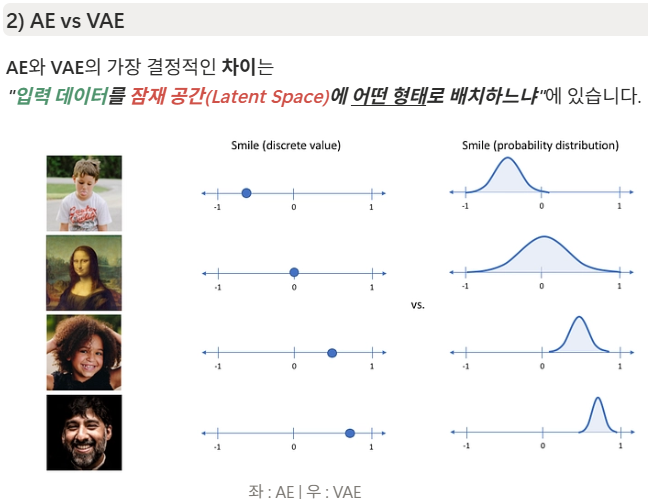

[AE의 잠재 공간]
- 입력 데이터를 잠재 공간의 어떤 하나의 고정된 수치(점)로 매핑
- 한계: 데이터가 찍히지 않은 '빈 공간'은 모델이 학습해본 적 없는 구역

[VAE의 잠재 공간]
- 잠재 코드 값이 평균(
𝜇
μ﻿)과 분산(
𝜎
2
σ 
2
 ﻿)으로 표현되는 어떤 가우시안 분포(확률 분포)

 - 구조적 특징
    - 연속성 : 잠재 공간의 가까운 두 점은 서로 유사한 특징을 갖게 됩니다
    - 조밀함 : 모든 데이터가 표준 정규 분포(
𝑁
(
0
,
1
)
N(0,1)﻿) 주변에 모이도록 강제되므로, 잠재 공간에 학습되지 않은 '빈틈'이 거의 생기지 않습니다

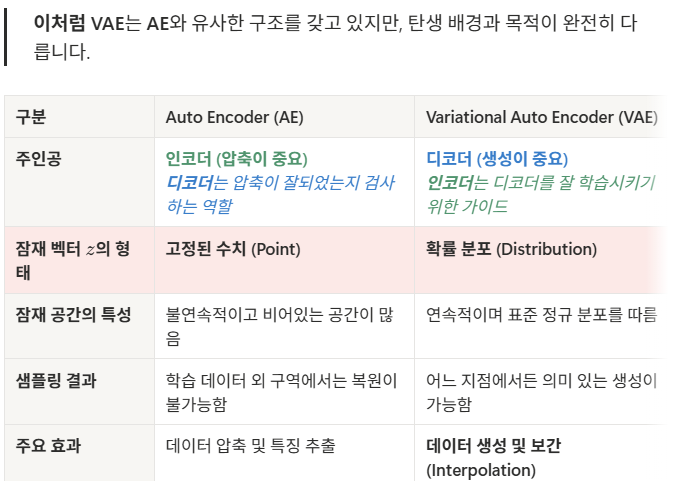

3) VAE의 구조와 작동 : 찾고, 뽑고, 다시 그리기!
VAE는 데이터를 고정된 점이 아닌 확률 분포로 변환하여 학습합니다. 
그 과정을 3단계로 나누어 차근차근 살펴봅시다!

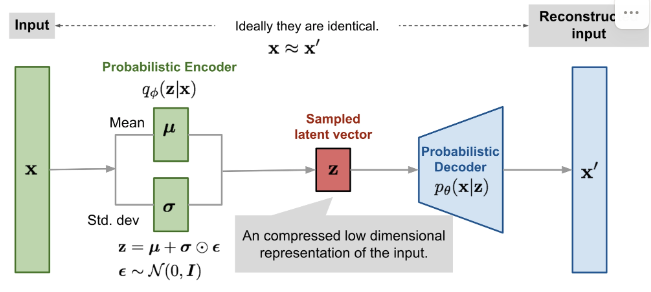

[Step 1] 분포 예측 단계 (Encoder)
역할: 입력 데이터를 특정 점이 아닌, 데이터가 존재할 확률이 높은 '구역'으로 매핑합니다.
인코더(
𝑞
𝜙
q 
ϕ
​
 ﻿): 입력 데이터(
𝑥
x﻿)를 분석해 잠재 공간상의 평균(
𝜇
μ﻿)과 표준편차(
𝜎
σ﻿)를 계산합니다.

[Step 2] 샘플링 및 재파라미터화 (Sampling & Reparameterization)
예측한 분포에서 실제 디코더에 전달할 잠재 벡터(
𝑧
z﻿)를 하나 뽑는 단계입니다.
샘플링: 인코더가 찾은 범위(
𝜇
,
𝜎
μ,σ﻿) 안에서 무작위로 점 하나(잠재 벡터(
𝑧
z﻿))를 추출합니다.
잠재 벡터(
𝑧
z﻿, Latent Vector)
재파라미터화 트릭(Reparameterization Trick)

[Step 3] 생성 단계 (Decoder)
샘플링된 잠재 벡터(
𝑧
z﻿)를 단서로 사용하여 새로운 데이터를 생성합니다.
디코더(
𝑓
𝜃
f 
θ
​
 ﻿): 저차원의 핵심 정보(
𝑧
z﻿)를 다시 고차원의 데이터로 복원(
𝑥
′
x 
′
 ﻿)합니다.(reconstruct)



3. GAN

3.1 GAN의 개념

1) GAN(Generative Adversarial Network)이란?
GAN(Generative Adversarial Network, 생성적 적대 신경망)은 생성자 신경망과 판별자 신경망이 서로 적대적으로 경쟁하면서, 훈련을 통하여 자신의 작업을 점점 더 정교하게 수행하는 신경망 모델입니다.

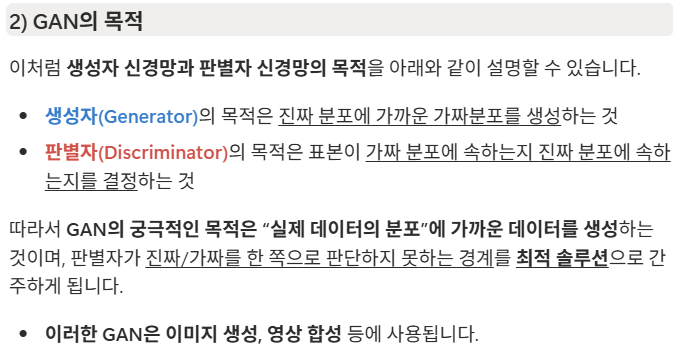

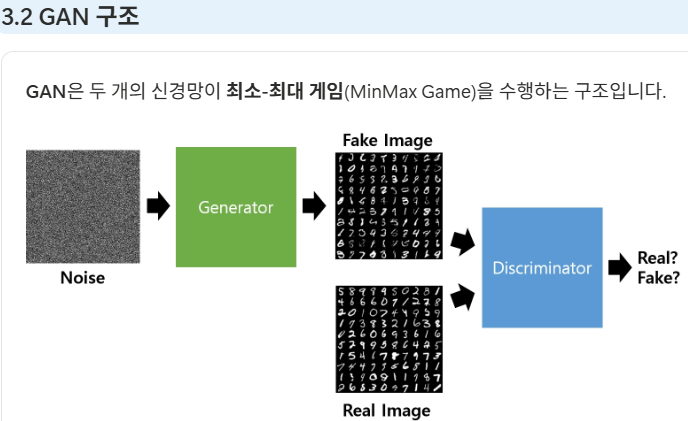

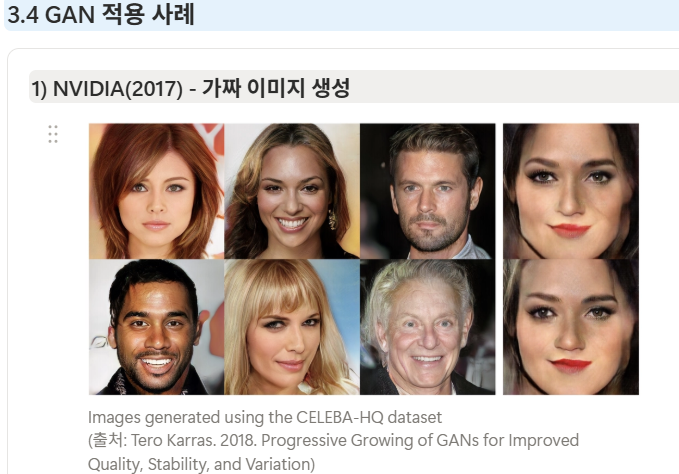

- NVIDIA는 Generator와 Discriminator를 둘 다 낮은 ‘결과값’에서 시작하여 훈련이 진행되면서 모델이 아주 서서히 ‘학습’하도록 새로운 레이어를 쌓아가며 점진적으로 성장시키는 새로운 훈련 방법론을 제시
- 사물도 실제와 같은 이미지로 만들어낼 수 있음을 보여주고 있으며, 저해상도의 사진을 고해상도로 만드는 등 손상된 이미지를 복원할 때에도 활용


4. 확산 모델(Diffusion Model)
4.1 확산 모델(Diffusion Model)의 개념

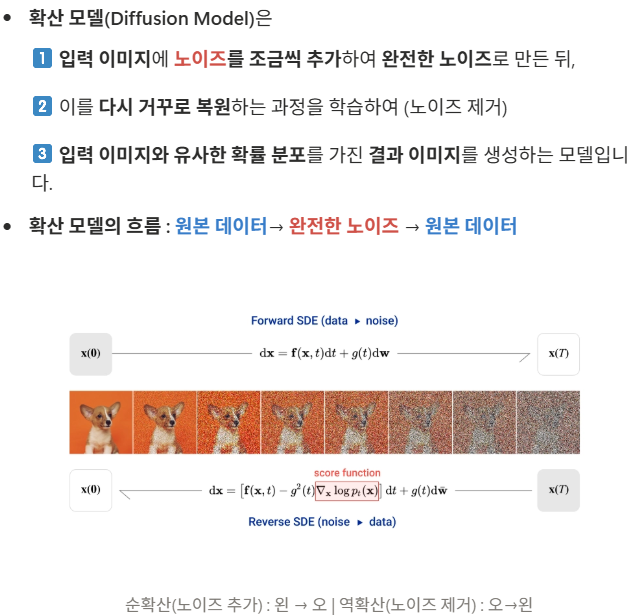

2) 확산 모델의 목적
- 목표: 순확산과 역확산 단계를 거쳐 생성된 '결과 이미지'의 확률 분포를 '원래 데이터'의 확률 분포와 최대한 유사하게 만드는 것입니다.
- 모호성 모델링: "유니콘을 그려줘"라는 모호한 요청에 대해, 모델은 완전한 노이즈 상태에서 시작해 데이터 구조의 아주 작은 부분을 조금씩 '환각(=상상)'하며 구체적인 유니콘 이미지를 완성해 나갑니다.

1) 순확산 (Forward Diffusion Process)

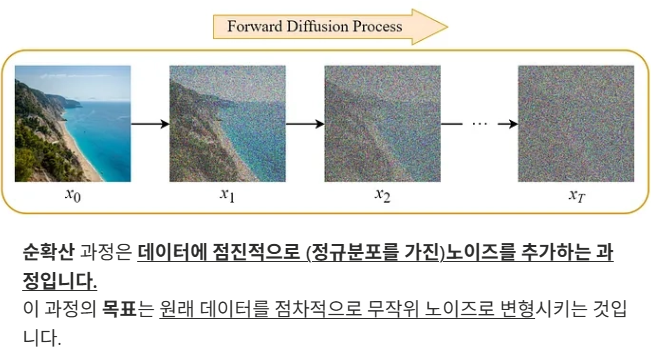

1. **시작** : 순확산 과정은 **원본 데이터**에서 시작합니다. 예를 들어, 이미지 데이터를 사용한다고 가정하면, 원본 이미지는 깨끗한 상태입니다.
2. **노이즈 추가**: 원본 데이터에 점진적으로 노이즈를 추가합니다. 이 단계는 여러 번 반복되며, 각 단계에서 데이터에 조금씩 노이즈가 추가됩니다.
3. **결과** : 충분히 많은 단계가 지나면, 원본 데이터는 **완전한 무작위 노이즈**로 변합니다.

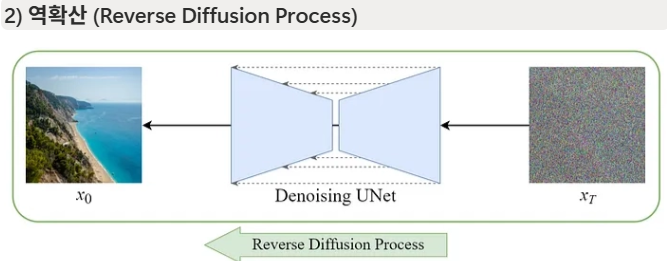  
역확산(Reverse Diffusion) 과정은 노이즈 데이터에서 원본 데이터를 재구성하는 과정입니다. 이 과정의 목표는 순확산 과정에서 추가된 노이즈를 제거하여 원래의 데이터를 복원하는 것입니다. 



# AI 최적화 강의자료

0. AI 최적화와 정렬

즉, AI 최적화와 정렬은 잘 만들어진 AI를 효율적으로 활용하고 (최적화)  
사람한테 진짜 도움이 되도록 다듬는 것 (정렬)  
이라고 할 수 있습니다.

1. 전이학습과 딥러닝 경량화

### (1) 전이학습이란?

<aside>

#### 딥러닝 모델의 한계

**전이학습**은 왜 필요할까요? 여러가지 딥러닝 모델들을 이용해 AI를 만드는 과정에서, 우리는 **데이터 부족 문제, 계산 시간과 비용의 증가, 과적합 발생**과 같은 어려움에 직면하게 됩니다.

- (참고) 데이터 부족 문제, 계산 시간과 비용의 증가, 과적합 발생
    1. **데이터 부족 문제** : 특정 도메인(예: 의료 영상, 희귀 언어, 특정 산업 공정 데이터)은 데이터를 수집하거나 전문가가 직접 라벨링하는 데 막대한 비용과 시간이 소요됩니다.
    2. **계산 시간과 비용** : 모델의 규모가 커질수록 최적의 가중치를 찾아가는 수렴(Convergence) 속도가 느려지며, 이는 하드웨어 비용과 탄소 배출 등 경제적·환경적 부담으로 이어집니다.
    3. **과적합 발생** : 데이터가 적은 환경에서 모델을 처음부터 학습시키면, 모델이 해당 데이터에만 과도하게 맞춰지는 과적합(Overfitting) 문제가 발생하기 쉽습니다.
    
    <aside>
    
    예를 들어, 병원에서 희귀 질환 진단 AI를 만들고 싶다고 해 봅시다. 그런데 우리는 환자 데이터가 100개밖에 없어요. 이 데이터만으로 처음부터 모델을 학습시키면?
    
    - 데이터가 너무 적으니 모델이 그 100개에만 딱 맞게 외워버려요 → **과적합**
    - 그렇다고 더 큰 모델을 쓰면 학습에 돈이 엄청 들어요 → **계산 비용**
    - 희귀 질환이라 데이터 자체를 더 모으기도 힘들어요 → **데이터 부족**
    </aside>
    

> 그렇다면 이를 해결하기 위해 이미 어디선가 학습된 내용을 가져다가 쓸 수는 없을까? 
**→ Transfer learning(전이학습)!**
> 
</aside>


- 전이학습의 정의
- 전이학습의 정의를 이해하기 위해서는 도메인과 태스크, 소스와 타겟이라는 네 가지 개념을 먼저 살펴볼 필요가 있음

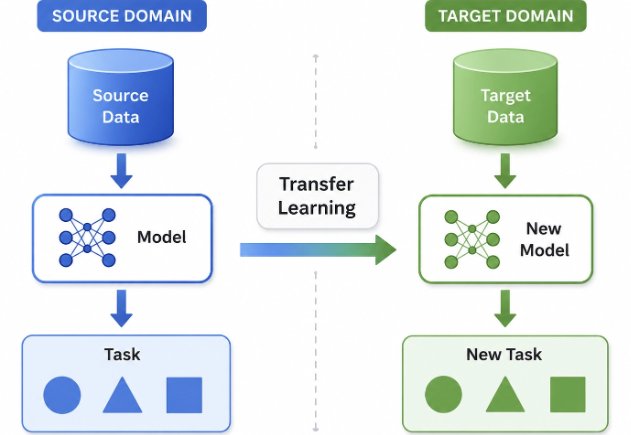

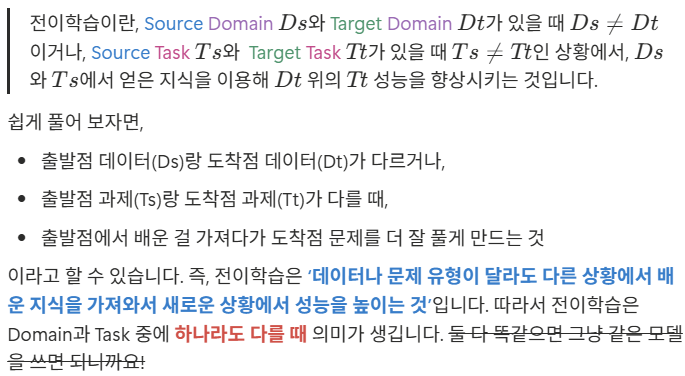


(2) 전이학습의 분류
도메인과 태스크에 따른 분류
전이학습을 분류할 때, 도메인과 태스크의 상태에 따라 다음과 같이 구분할 수 있습니다.
1. 귀납적 전이학습 (Inductive TL)
: 소스와 타겟의 task가 다르고 타겟 도메인에 라벨이 존재할 때

2. 트랜스듀서형 전이학습 (Transductive TL)
: 소스와 타겟의 task는 같지만 도메인이 다를 때

3. 비지도 전이학습 (Unsupervised TL)
: 소스와 타겟의 task가 다르고 소스와 타겟 모두 라벨이 없을 때

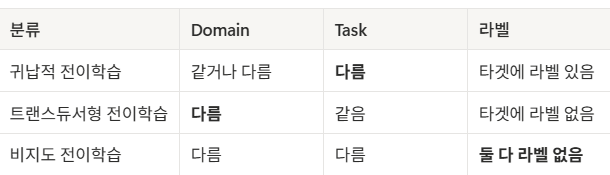  
출발점과 도착점이 다를 때 지식(학습 내용)을 옮겨 사용한다(전이한다)

무엇을 전이하느냐에 따른 분류

- **인스턴스(Instance):** 소스 데이터 중 타겟에 도움이 될만한 샘플을 골라 가중치를 부여합니다. (데이터 레벨의 전이)
- **특징(Feature):** 소스와 타겟의 공통적인 특징을 추출할 수 있는 '표현 방식'을 전이합니다. (표현 레벨의 전이)
- **파라미터(Parameter):** 모델의 가중치($W$)나 하이퍼파라미터 초기값을 그대로 가져옵니다**. 현재 딥러닝에서 가장 주류가 되는 방법입니다.**
    - (참고) 파라미터 전이
        
        지금 우리가 쓰는 GPT, BERT 같은 모델들은 전부 **파라미터 전이** 방식이라고 합니다. 즉, 잘 학습된 모델의 가중치를 그대로 가져다 쓰는 것이죠.
        
        <aside>
        
        **BERT 모델**을 예시로 들어 보면,
        
        - 엄청 큰 데이터로 미리 학습 (**pretraining**)
        - 그 가중치를 그대로 가져옴
        - 내가 원하는 작업에 맞게 조금만 수정 (**fine-tuning**)
        
        의 방법을 **파라미터 전이**라고 할 수 있습니다. 아래에서 더 자세하게 다룹니다!
        
        </aside>

    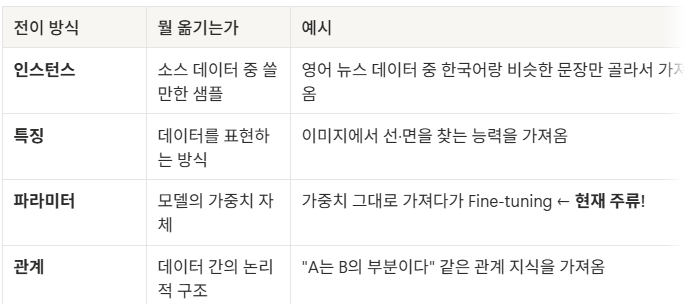

- 트랜스포머 이전의 전이학습
- 트랜스포머 이전에는 사실 "사전 학습된 좋은 모델"이라는 개념 자체가 지금처럼 당연하지 않았습니다. 다들 각자 모델을 처음부터 만들었어요. 전이학습은 존재했지만, 주로 CNN의 ImageNet 가중치를 가져오는 수준이었습니다.

#### 트랜스포머 이후의 전이학습

트랜스포머의 등장 이후, 판이 완전히 바뀌었습니다. 엄청난 양의 데이터로 **사전 학습된 거대 모델 (Pre-trained Model)** 들이 등장하기 시작했고, 전이학습의 질문 자체가 바뀌게 됩니다.

> *이전 : "어떻게 지식을 옮기지?"
이후 : "이미 잘 학습된 거대 모델을 내 용도에 맞게 어떻게 조정하지?"*

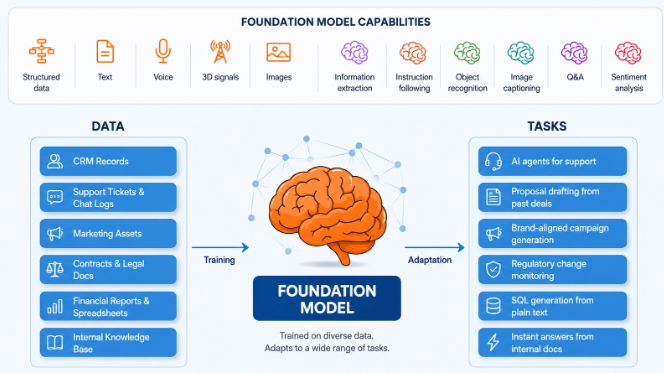

GPT나 Gemini처럼 수만 가지 일을 할 수 있는 지능의 기반이 되는 거대 모델들을 Foundation Model(파운데이션 모델)이라고 부름



(4) Fine-tuning의 한계를 넘어서

PEFT: (Parameter-Efficient Fine-Tuning)입니다. “최소한의 파라미터만 건드려서 최대의 성능을 내자”는 전략

Zero-shot Transfer는 학습 데이터가 없어도, 언어 이해 능력만을 기반으로 바로 추론을 수행하는 것
Few-shot Transfer(In-Context Learning)은 극소수의 예시만으로 새로운 태스크를 수행하는 것

N- egative Transfer
- Source와 Target의 도메인이 너무 다르면 오히려 전이가 성능을 떨어트립니다. 잘못 배운 습관은 계속 방해가 되는 것처럼요. 이를 해결하기 위해 도메인 간 거리를 측정하는 지표로 Maximum Mean Discrepancy(MMD) 같은 개념이 연구되고 있지만, 사전에 정확히 예측하기는 여전히 어렵습니다.

- Catastrophic Forgetting
- Fine-tuning 과정에서 새 데이터에 너무 치우치면, 모델이 원래 가지고 있던 일반 능력을 잃어버립니다. 한식을 너무 집중적으로 배운 셰프가 파스타 만드는 법을 잊어버리는 것입니다. 이를 완화하기 위한 접근으로 Elastic Weight Consolidation(EWC) 같은 방법이 연구되고 있습니다.

- Bias Transfer
- 사전 학습 데이터에 담긴 편향이 그대로 넘어오게 되는 것입니다. 인터넷 텍스트로 학습된 모델이 특정 인종, 성별에 대한 편향을 내재하고 있을 수 있는 것이 예시입니다. Fine-tuning으로 완전히 제거하기가 어려우며, 기술적 문제이기도 하지만 사회적 책임의 문제가 되기도 합니다.
- Transferability 측정의 어려움
- 어떤 두 Task가 얼마나 관련되어 있는지를 사전에 정량적으로 측정하기 어렵습니다. LEEP, LogME 같은 지표들이 연구되고 있지만, 아직 완전히 해결된 문제는 아닙니다.

(6) 전이학습 사용 사례

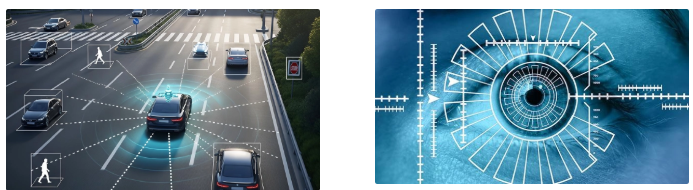

#### ① 컴퓨터 비전 (CV)

**의료 영상 분석**

ImageNet으로 학습된 ResNet 같은 모델을 가져다가, 폐암 X-ray 판독이나 안과 질환 진단 AI를 만드는 데 사용합니다. 처음부터 학습하려면 수십만 장의 의료 데이터가 필요하지만, 전이학습을 쓰면 수천 장만 있어도 충분하기 때문이에요. 구글 DeepMind가 이 방식으로 안과 질환 진단 AI를 만들었고, 전문의 수준의 성능을 달성했습니다.

**자율주행**

도로, 보행자, 신호등을 인식하는 모델도 ImageNet 가중치에서 출발합니다. 자율주행 전용 데이터를 처음부터 모으고 학습하는 건 비용도 크고 위험하기도 하니까요. 전이학습 덕분에 훨씬 적은 데이터로 빠르게 시작할 수 있게 되었습니다.

② 자연어 처리 (NLP)
법률 문서 분석

BERT를 법률 텍스트로 Fine-tuning하면, 계약서에서 위험 조항을 자동으로 찾아주는 AI가 됩니다. 법률 데이터는 전문가 라벨링 비용이 엄청난데, PEFT 방식을 활용하면 적은 데이터로도 좋은 성능을 낼 수 있어요.

기업 특화 챗봇

GPT 같은 모델을 회사 FAQ 데이터로 Fine-tuning해서, 특정 회사에 특화된 고객 서비스 챗봇을 만들기도 합니다. 카카오, 네이버 같은 국내 기업들도 이 방식을 활용하고 있다고 해요.

③ 의료 · 신약 개발

단백질 구조 예측

구글 DeepMind의 AlphaFold도 전이학습 개념을 활용합니다. 기존에 알려진 단백질 구조 데이터로 학습한 뒤, 새로운 단백질 구조 예측에 적용하는 방식입니다. 수십 년이 걸리던 신약 개발 과정을 획기적으로 단축시킬 수 있다는 점에서 주목받고 있습니다.

④ 제조 · 산업

공장 불량 검출

정상 제품 이미지로 학습된 비전 모델을 가져다가, 특정 공장의 불량 패턴을 찾도록 Fine-tuning하기도 합니다. 불량품 데이터는 당연히 그 숫자가 적을 수밖에 없는데, 전이학습 덕분에 적은 데이터로도 높은 정확도를 달성할 수 있어요.

### (7) 딥러닝 경량화

딥러닝 경량화 기술에는 **가지치기(Pruning), 양자화(Quantization), 지식 증류(Knowledge Distillation), 모델 자체 경량화, 하드웨어 가속화** 등의 방법이 있습니다.

가지치기: 별로 중요하지 않은 것들을 그냥 잘라내는 방법

양자화: 모델의 가중치를 표현하는 숫자의 정밀도를 줄이는 방법

지식 증류:  크고 똑똑한 모델(Teacher)의 지식을 작은 모델(Student)에게 가르쳐 주는 방법

모델 구조 경량화 (Model Architecture Optimization):  처음부터 가볍게 설계된 모델을 쓰는 방법

하드웨어 가속화 (Hardware Acceleration): AI 연산에 특화된 하드웨어를 쓰는 방법


2. AI Alignment

AI Alignment(인공지능 정렬)는 단순히 모델의 성능을 높이는 단계를 넘어,
AI가 인간의 의도(Intent), 목표(Goal), 그리고 윤리적 가치(Values)에 부합하도록 행동
하게 만드는 연구 분야입니다.

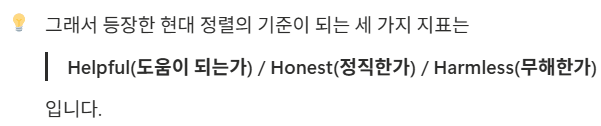

1. Outer Alignment: "목표를 제대로 설정했는가?"
2. Inner Alignment: "모델이 내면에서 무엇을 최적화하는가?"

정렬을 어렵게 만드는 요인들
① 가치 정렬의 모호성 (Value Alignment Problem)
② 확장 가능한 감독 (Scalable Oversight)

모델이 문장은 잘 생성하지만, 사람이 원하는 답을 이해하지는 못해 원하는 답변을 제공하지 못하는 Outer Alignment 문제가 존재했습니다. 
RLHF(Reinforcement Learning from Human Feedback)는 이를 해결하기 위해 인간의 피드백을 기반으로 모델을 강화학습으로 조정하는 방법





3. 프롬포트 엔지니어링

프롬프트 엔지니어링은 AI가 더 좋은 답변을 내도록 입력을 설계하는 기술

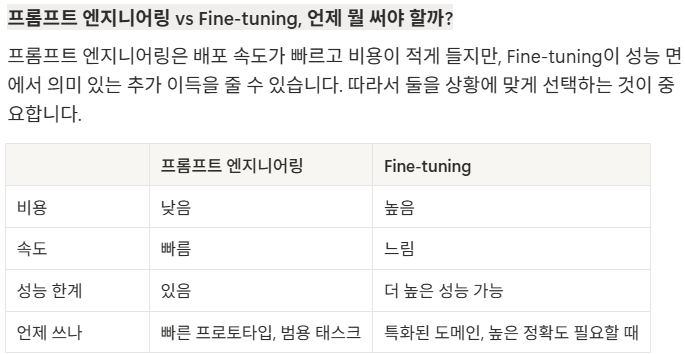

